<h1 style="text-align: center; font-size: 40px; font-weight: bold; text-decoration: underline;">
    TP Apprentissage et Analyse de données
</h1>

<h3 style=" font-weight: bold; text-decoration: underline; text-align: center;">
    Étudiants:
</h3>
<p style="text-align: center;">
    MOSSIERE Erwan (p2204008) <br>
    VERLANDE Augustin (p2309122) <br>
    VILLAUME Evan (p2503961)
</p>

<h2 style="font-weight: bold; text-decoration: underline;">
   0. Import des bibliothèques nécessaires.
</h2>

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import requests
import json

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, make_scorer, roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import cross_validate
from sklearn import metrics
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
np.set_printoptions(threshold=10000, suppress=True)

<h3 style="font-weight: bold; text-decoration: underline;">
</h3>

<h2 style="font-weight: bold; text-decoration: underline;">
   I. Apprentissage supervisé : Feature engineering et Classification.
</h2>

<h3 style="font-weight: bold; text-decoration: underline;">
    1. Chargement des données et préparation.
</h3>

<h5 style="font-weight: bold;">
        Importation du jeu de données avec panda.
</h5>

In [2]:
dataform = pd.read_csv('credit_scoring.csv', sep=';')

<h5 style="font-weight: bold;">
        Transformation et séparation du jeu de données.
</h5>

In [3]:
columns_name = list(dataform.columns.values)
df = dataform.values

# Variables caractéristiques
vc = df[:,:-1]

# Variables à prédire
vp = df[:,-1]

<h5 style="font-weight: bold;">
    Analyse des propriétés des données.
</h5>

In [4]:
taille_echantillon = vp.shape[0]

classes, counts = np.unique(vp, return_counts=True)
percentages = (counts / vp.shape[0]) * 100

exemples_positifs = f"{counts[0]} ({percentages[0]:.2f}%)"
exemples_negatifs = f"{counts[1]} ({percentages[1]:.2f}%)"

print(f"Taille échantillon : {taille_echantillon}\nExemples positifs : {exemples_positifs}\nExemples négatifs : {exemples_negatifs}")

Taille échantillon : 4375
Exemples positifs : 1216 (27.79%)
Exemples négatifs : 3159 (72.21%)


<h5 style="font-weight: bold;">
    Séparation des données en ensembles d'entraînement et de test.
</h5>

In [5]:
vc_train, vc_test, vp_train, vp_test = train_test_split(vc, vp, test_size=0.5, random_state=1)

<h4 style="font-weight: bold; text-decoration: underline;">
</h4>

<h3 style="font-weight: bold; text-decoration: underline;">
    2. Apprentissage et évaluation de modèles.<br>
    3. Normalisation des variables continues.<br>
    4. Création de nouvelles variables caractéristiques par combinaisons linéaires des variables initiales
</h3>

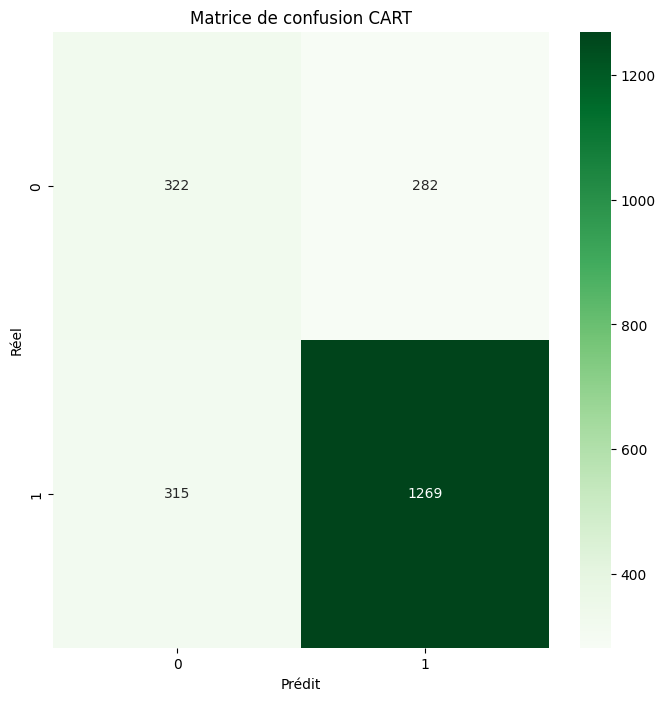

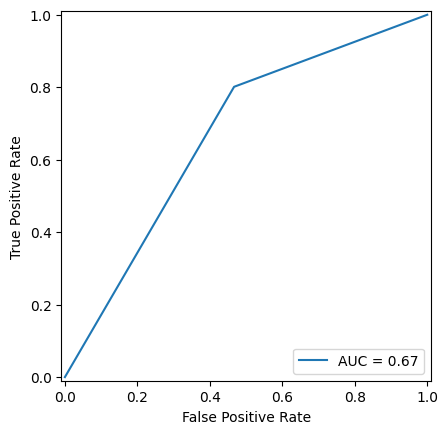

Précision : 0.82
Rappel : 0.80
Accuracy for CART : 0.73

Best : Précision with 0.82
Score final pour CART : 0.7726649493102875


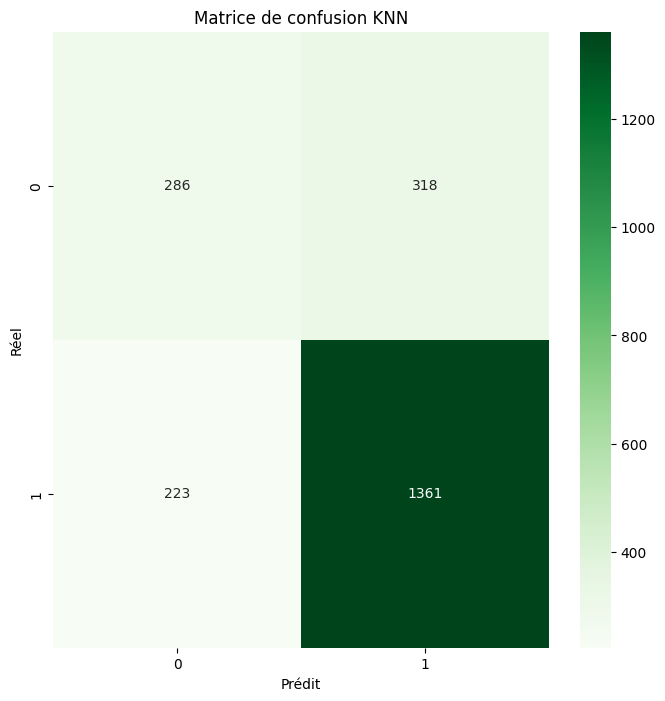

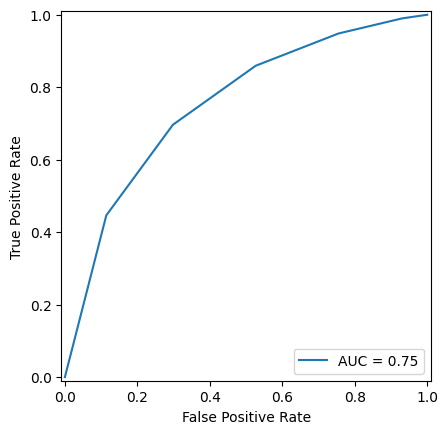

Précision : 0.81
Rappel : 0.86
Accuracy for KNN : 0.75

Best : Rappel with 0.86
Score final pour KNN : 0.8059797010322605


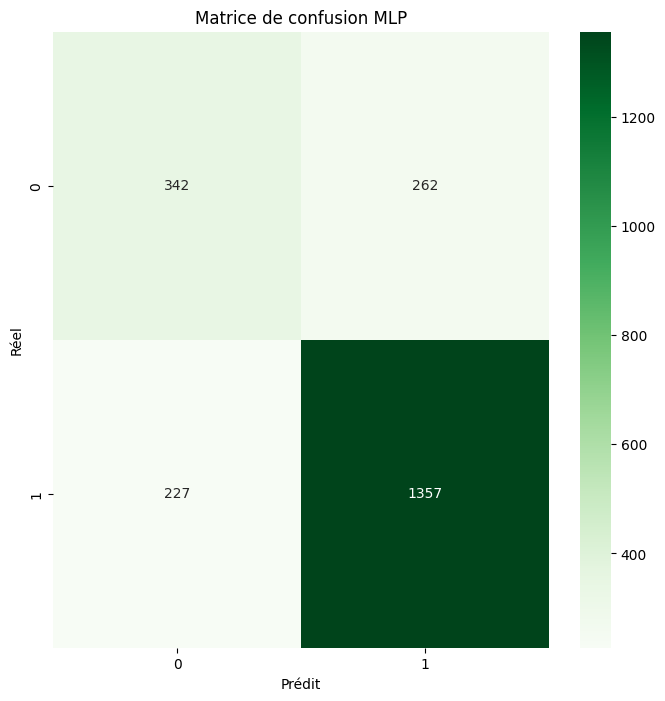

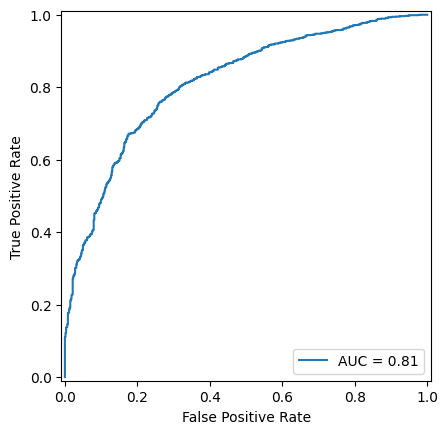

Précision : 0.84
Rappel : 0.86
Accuracy for MLP : 0.78

Best : Rappel with 0.86
Score final pour MLP : 0.8166000729414806


In [6]:
# Classifieurs
classifiers = {
    "CART": DecisionTreeClassifier(random_state=1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "MLP": MLPClassifier(hidden_layer_sizes=(40, 20), random_state=1)
}

# Par défaut normalize = True, spécifier False si on souhaite conserver les données telles quelles
# Par défaut ACP = False
def run_classifiers_train_test(classifiers, X_train, X_test, y_train, y_test, normalize=True, acp=False):

    scores = {}
    
    if acp:
        pca = PCA(n_components=3)
        X_train= pca.fit_transform(X_train)
        X_test = pca.transform(X_test)

    if normalize:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
    
    for name, model in classifiers.items():
        model.fit(X_train, y_train)
        scores[name] = evaluate(model, X_test, y_test, name)

    best_model_name = max(scores, key=scores.get)
    return X_train, X_test, best_model_name, scores[best_model_name]

# Fonction d'évaluation
def evaluate(model, X_test, y_test, name):

    y_pred = model.predict(X_test) 

    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)

    # Matrice de confusion
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f"Matrice de confusion {name}")
    plt.ylabel('Réel')
    plt.xlabel('Prédit')
    plt.show()

    # Afficher ROC (Receiver Operating Curve) et AUC (Area Under the Curve)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:,1]
    elif hasattr(model, "decision_function"):
        y_proba = model.decision_function(X_test)
    else:
        print("ROC non disponible pour ce modèle")

    # Affichage matrice de confusion et courbe ROC avec AUC
    fpr, tpr, _ = roc_curve(y_test, y_proba, pos_label=1.0)
    roc_auc = metrics.auc(fpr, tpr)
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
    display.plot()
    plt.show()

    # Meilleur score pour chaque modèle
    acc = accuracy_score(y_test, y_pred)
    score = model.score(X_test, y_test)
    prec = precision_score(y_test, y_pred, pos_label=1.0)
    rec = recall_score(y_test, y_pred, pos_label=1.0)
    best_criteria = max(prec, rec)

    best_name = "Rappel" if prec <= rec else "Précision"
    print(f"Précision : {prec:.2f}")
    print(f"Rappel : {rec:.2f}")
    print(f"Accuracy for {name} : {score:.2f}")
    print(f"\nBest : {best_name} with {best_criteria:.2f}")

    # Meilleur score final
    final_score = (acc + best_criteria) / 2
    print(f"Score final pour {name} : {final_score}")
    return final_score;

X_train_trans, X_test_trans, best_model, best_score = run_classifiers_train_test(
    classifiers,
    vc_train,
    vc_test,
    vp_train,
    vp_test,
    normalize=True,
    acp=False
)

<h4 style="font-weight: bold; text-align: center;">
    Observation et Conclusion
</h4>

D'après les scores que nous avons obtenu, le meilleur algorithme est le **Multilayer Perceptron (MLP)** avec les paramètres de **normalisation** et de l'**ACP**. <br>
Il faut donc **normaliser** les données pour optimiser les performances et prendre les trois composantes principales de l'**ACP** pour réduire la dimension et capturer les structures les plus discriminantes. <br>
On peut aussi observer ici que le paramètre avec le meilleur score est le **Rappel**, cependant pour la suite de ce TP nous allons utiliser la **Précision**.

*Pourquoi utiliser la précision plutôt que le rappel qui a un meilleur score ?* 

La précision est plus adaptée si l'on préfère avoir des faux négatifs. Par exemple, si une personne se voit refuser un crédit qu'elle aurait pu rembourser, c'est moins "grave" pour la banque. Le rappel est, lui à l'inverse, plutôt centré sur les faux positifs, c'est à dire qu'il a plus de chances d'accepter le crédit d'une personne en incapacité de le rembourser. Une banque préfèrera manquer un "bon payeur", plutôt que d'avoir un "mauvais payeur".

<h3 style="font-weight: bold; text-decoration: underline;">
   5. Sélection de variables.
</h3>

<h5 style="font-weight: bold;">
    Première fonction : Importance des variables.
</h5>

['Income' 'Seniority' 'Price' 'Amount' 'Age' 'Assets' 'Expenses' 'Records'
 'Time' 'Job' 'Debt' 'Home' 'Marital']


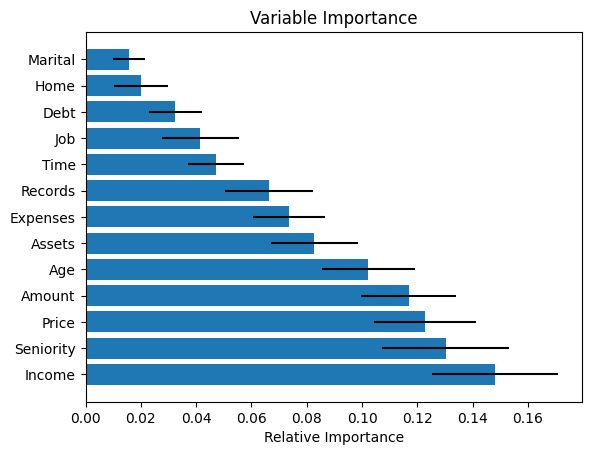

In [7]:
y_train = vp_train

# Calculer et afficher les variables avec random forest
def random_forest(X_train, y_train, nom_cols):
    clf = RandomForestClassifier(n_estimators=1000,random_state=1)
    clf.fit(X_train, y_train)
    importances=clf.feature_importances_
    std = np.std([tree.feature_importances_ for tree in clf.estimators_],axis=0)
    sorted_idx = np.argsort(importances)[::-1]
    
    features =nom_cols
    print(np.array(features)[sorted_idx])
    
    padding = np.arange(X_train.size/len(X_train)) + 0.5
    plt.barh(padding, importances[sorted_idx],xerr=std[sorted_idx], align='center')
    plt.yticks(padding, np.array(features)[sorted_idx])
    plt.xlabel("Relative Importance")
    plt.title("Variable Importance")
    plt.show()

    return sorted_idx

sorted_idx = random_forest(X_train_trans, y_train, columns_name)
#sorted_idx = random_forest(X_train_trans, y_train, ["Seniority", "Income", "Price"])

**Observations :** On peut voir sur le graphique que les variables qui ont le plus d'importance sont *Price*, *Seniority* et *Income*.

<h5 style="font-weight: bold;">
    Deuxième fonction : Sélection du nombre optimal de variables.
</h5>

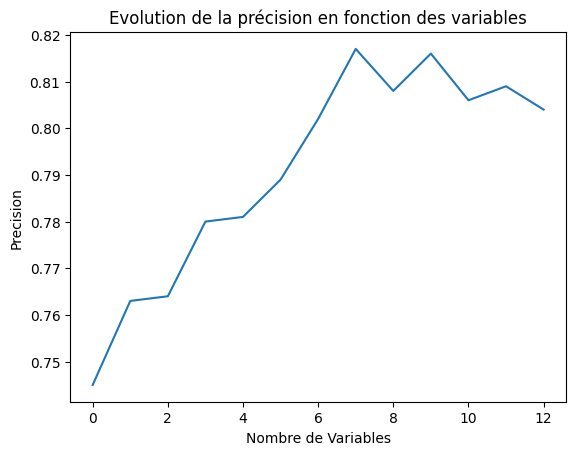

Nombre de variables optimal :  8


In [8]:
# Sélection du nombre optimal de variables
def select_optimal_variables(X_train, X_test, y_train, y_test, sorted_idx):
    MLP= MLPClassifier(hidden_layer_sizes=(40, 20), random_state=1)
    scores=np.zeros(X_train.shape[1])
    for f in np.arange(0, X_train.shape[1]):
        X1_f = X_train[:,sorted_idx[:f+1]]
        X2_f = X_test[:,sorted_idx[:f+1]]
        MLP.fit(X1_f,y_train)
        YMLP=MLP.predict(X2_f)
        accuracy = accuracy_score(y_test, YMLP)
        precision = precision_score(y_test,YMLP)
        mean = (accuracy + precision) / 2
        scores[f]=np.round(mean, 3)
        
    plt.plot(scores)
    plt.xlabel("Nombre de Variables")
    plt.ylabel("Precision")
    plt.title("Evolution de la précision en fonction des variables")
    plt.show()

    optimal_var = np.argmax(scores) + 1
    print(f"Nombre de variables optimal : ", optimal_var)

    return scores

scores = select_optimal_variables(
    X_train_trans,
    X_test_trans,
    vp_train,
    vp_test,
    sorted_idx
)

**Observations :** On constate que la précision varie en fonction du nombre de variables utilisées. Dans notre cas, si l'on souhaite obtenir une précision optimale, il faut utiliser *8*  variables.

<h3 style="font-weight: bold; text-decoration: underline;">
  6. Paramétrage des classifieurs.
</h3>

In [9]:
def custom_metric(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    return (acc + prec) / 2

custom_scorer = make_scorer(custom_metric, greater_is_better=True)


def getParam(X_train, y_train):
    MLP = MLPClassifier(random_state=1)
    param = {"hidden_layer_sizes" : [(20,),(40,)]}
    grid = GridSearchCV( MLP,param,scoring=custom_scorer, cv=5)
    grid.fit(X_train, y_train)
    print("Meilleurs paramètres :", grid.best_params_)
    print("Score moyen :", grid.best_score_)
    return grid.best_params_

best_model = getParam(X_train_trans, y_train)

Meilleurs paramètres : {'hidden_layer_sizes': (40,)}
Score moyen : 0.8078766500274842


<h3 style="font-weight: bold; text-decoration: underline;">
  7. Création d’un pipeline
</h3>

In [10]:
def generer_et_sauvegarder_pipeline(model, X, y, n_features, use_pca=False, nom_fichier="credit_scoring.pkl"):
    
    steps = []
    steps.append(('scaler', StandardScaler()))

    if use_pca:
        steps.append(('pca', PCA(n_components=3)))

    selecteur = SelectFromModel(
        estimator=RandomForestClassifier(n_estimators=300, random_state=1),
        max_features=n_features,
        threshold=-np.inf
    )
    steps.append(('selection', selecteur))
    steps.append(('model', model))

    pipeline_final = Pipeline(steps)
    print(f"Entraînement du pipeline sur {len(X)} individus avec {n_features} variables...")
    pipeline_final.fit(X, y)
    with open(nom_fichier, 'wb') as f:
        pickle.dump(pipeline_final, f)
    print(f"Pipeline sauvegardé avec succès : {nom_fichier}")
    return pipeline_final  

In [11]:
nb_variables = 8

param = getParam(X_train_trans, y_train)
mon_meilleur_model = MLPClassifier(**param, random_state=1)

pipeline_entraine = generer_et_sauvegarder_pipeline(
    model=mon_meilleur_model,
    X=vc_train,
    y=vp_train,
    n_features=nb_variables,
    use_pca= False,
    nom_fichier="credit_scoring.pkl"
)

Meilleurs paramètres : {'hidden_layer_sizes': (40,)}
Score moyen : 0.8078766500274842
Entraînement du pipeline sur 2187 individus avec 8 variables...
Pipeline sauvegardé avec succès : credit_scoring.pkl


<h4 style="font-weight: bold; text-align: center;">
    Affichage du pipeline
</h4>

In [12]:
with open("credit_scoring.pkl", "rb") as f:
    mon_pipeline_charge = pickle.load(f)

print("Le pipeline a été chargé avec succès")
print(mon_pipeline_charge)

Le pipeline a été chargé avec succès
Pipeline(steps=[('scaler', StandardScaler()),
                ('selection',
                 SelectFromModel(estimator=RandomForestClassifier(n_estimators=300,
                                                                  random_state=1),
                                 max_features=8, threshold=-inf)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(40,), random_state=1))])


<h3 style="font-weight: bold; text-decoration: underline;">
  8. Orchestration
</h3>

In [13]:
from utils import pipeline_generation_train_test_split
pipeline = pipeline_generation_train_test_split(vc, vp)

print("Pipeline généré :", pipeline)

with open("credit_scoring.pkl", "rb") as f:
    p = pickle.load(f)

p.predict(vc_test)

Pipeline généré : Pipeline(steps=[('scaler', StandardScaler()),
                ('selection',
                 SelectFromModel(estimator=RandomForestClassifier(n_estimators=300,
                                                                  random_state=1),
                                 max_features=8, threshold=-inf)),
                ('model',
                 MLPClassifier(hidden_layer_sizes=(20,), random_state=1))])


array([1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0.,
       1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 0.,
       1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
       1., 0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 0.

<h3 style="font-weight: bold; text-decoration: underline;">
  9. Création d’une API FastAPI pour exécuter le pipeline
</h3>

In [14]:
import requests
import json

# Lancement : python -m uvicorn api:app --reload
# Manuel : http://127.0.0.1:8000/docs

url = "http://127.0.0.1:8000/predict/"

profils = [
    {
        "ref": "PROFIL A - Bon client",
        "data": {
            "Seniority": 25, "Home": 1, "Time": 12, "Age": 55, "Marital": 2, "Records": 1, 
            "Job": 3, "Expenses": 35, "Income": 500, "Assets": 50000, "Debt": 0, 
            "Amount": 500, "Price": 1000
        }
    },
    {
        "ref": "PROFIL B - Jeune",
        "data": {
            "Seniority": 2, "Home": 2, "Time": 24, "Age": 24, "Marital": 1, "Records": 1, 
            "Job": 2, "Expenses": 45, "Income": 140, "Assets": 2000, "Debt": 0, 
            "Amount": 1000, "Price": 1200
        }
    },
    {
        "ref": "PROFIL C - Endettement",
        "data": {
            "Seniority": 10, "Home": 1, "Time": 36, "Age": 45, "Marital": 2, "Records": 1, 
            "Job": 3, "Expenses": 90, "Income": 200, "Assets": 5000, "Debt": 4000, 
            "Amount": 2000, "Price": 2500
        }
    },
    {
        "ref": "PROFIL D - Risque important",
        "data": {
            "Seniority": 1, "Home": 2, "Time": 48, "Age": 30, "Marital": 1, "Records": 2, 
            "Job": 1, "Expenses": 50, "Income": 90, "Assets": 0, "Debt": 500, 
            "Amount": 3000, "Price": 3000
        }
    },
    {
        "ref": "PROFIL E - Revenus faibles (patrimoine)",
        "data": {
            "Seniority": 0, "Home": 1, "Time": 12, "Age": 68, "Marital": 3, "Records": 1, 
            "Job": 0, "Expenses": 30, "Income": 110, "Assets": 150000, "Debt": 0, 
            "Amount": 800, "Price": 800
        }
    }
]

header = f"{'REFERENCE CLIENT':<40} | {'STATUT':<10} | {'SCORE (ACCORD)':>15} | {'RISQUE (REFUS)':>15}"
print(header)
print("-" * len(header))

for p in profils:
    try:
        response = requests.post(url, json=p["data"])
        
        if response.status_code == 200:
            res = response.json()
            
            statut = "ACCORDE" if res['prediction'] == 1 else "REFUSE"
            score_accord = res.get('probabilite_accord', 0)
            score_refus = res.get('probabilite_refus', 0)
            
            print(f"{p['ref']:<40} | {statut:<10} | {score_accord:>15.2%} | {score_refus:>15.2%}")
            
        else:
            print(f"Erreur API pour {p['ref']}")

    except Exception as e:
        print(f"Erreur de connexion : {e}")

REFERENCE CLIENT                         | STATUT     |  SCORE (ACCORD) |  RISQUE (REFUS)
-----------------------------------------------------------------------------------------
Erreur de connexion : HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predict/ (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000020D6131C9D0>: Failed to establish a new connection: [WinError 10061] Aucune connexion n’a pu être établie car l’ordinateur cible l’a expressément refusée'))
Erreur de connexion : HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predict/ (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x0000020D61278290>: Failed to establish a new connection: [WinError 10061] Aucune connexion n’a pu être établie car l’ordinateur cible l’a expressément refusée'))
Erreur de connexion : HTTPConnectionPool(host='127.0.0.1', port=8000): Max retries exceeded with url: /predict/ (Cau

<h3 style="font-weight: bold; text-decoration: underline;">
  10. Comparaison de plusieurs algorithmes d’apprentissage
</h3>

In [15]:
clfs = {
    "CART": DecisionTreeClassifier(random_state=1),
    "ID3": DecisionTreeClassifier(criterion="entropy", random_state=1),
    "DecisionStump": DecisionTreeClassifier(max_depth=1, random_state=1),
    "MLP": MLPClassifier(hidden_layer_sizes=(20,10), random_state=1),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Bagging": BaggingClassifier(n_estimators=200, random_state=1),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=1),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=1),
    "XGBoost": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4)
}

def run_classifiers_cv(clfs, X, y):
    kf = KFold(n_splits=10, shuffle=True, random_state=0)
    results = {}

    for name, clf in clfs.items():
        print(f"\n=== {name} ===")
        start = time.time()
        acc = cross_val_score(clf, X, y, cv = kf, scoring = "accuracy")
        auc = cross_val_score(clf, X, y, cv = kf, scoring = "roc_auc")
        crit = cross_val_score(clf, X, y, cv = kf, scoring = custom_scorer)
        end = time.time()

        results[name] = {
            "accuracy_mean": acc.mean(),
            "accuracy_std": acc.std(),
            "auc_mean": auc.mean(),
            "auc_std": auc.std(),
            "crit_mean": crit.mean(),
            "crit_std": crit.std(),
            "time": end - start
        }
        print(f"Accuracy :  {acc.mean():.3f} +/- {acc.std():.3f}")
        print(f"AUC : {auc.mean():.3f} +/- {auc.std():.3f}")
        print(f"(Acc+Prec)/2 : {crit.mean():.3f} +/- {crit.std():.3f}")
        print(f"Temps : {end - start:.2f} sec")
    return results


<h5 style="font-weight: bold;">
    Données brutes : 
</h5>

In [16]:
res_raw = run_classifiers_cv(clfs, vc, vp)


=== CART ===
Accuracy :  0.727 +/- 0.025
AUC : 0.656 +/- 0.032
(Acc+Prec)/2 : 0.767 +/- 0.022
Temps : 0.99 sec

=== ID3 ===
Accuracy :  0.723 +/- 0.024
AUC : 0.664 +/- 0.029
(Acc+Prec)/2 : 0.769 +/- 0.026
Temps : 1.19 sec

=== DecisionStump ===
Accuracy :  0.722 +/- 0.018
AUC : 0.618 +/- 0.028
(Acc+Prec)/2 : 0.731 +/- 0.019
Temps : 0.26 sec

=== MLP ===
Accuracy :  0.707 +/- 0.069
AUC : 0.719 +/- 0.032
(Acc+Prec)/2 : 0.751 +/- 0.020
Temps : 18.16 sec

=== KNN ===
Accuracy :  0.715 +/- 0.017
AUC : 0.662 +/- 0.027
(Acc+Prec)/2 : 0.741 +/- 0.017
Temps : 0.88 sec

=== Bagging ===
Accuracy :  0.782 +/- 0.015
AUC : 0.823 +/- 0.020
(Acc+Prec)/2 : 0.804 +/- 0.014
Temps : 106.01 sec

=== AdaBoost ===
Accuracy :  0.796 +/- 0.015
AUC : 0.832 +/- 0.016
(Acc+Prec)/2 : 0.810 +/- 0.014
Temps : 25.93 sec

=== RandomForest ===
Accuracy :  0.786 +/- 0.015
AUC : 0.829 +/- 0.018
(Acc+Prec)/2 : 0.802 +/- 0.014
Temps : 36.87 sec

=== XGBoost ===
Accuracy :  0.793 +/- 0.015
AUC : 0.830 +/- 0.020
(Acc+Prec)/

**Observations :** On peut constater que sur les données brutes *AdaBoost* et *XGBoost* fournissent les meilleurs résultats. *XGBoost* est plus performant, il a le meilleur compromis temps/score .  

<h5 style="font-weight: bold;">
    Données normalisées : 
</h5>

In [17]:
scaler = StandardScaler()
vc_norm = scaler.fit_transform(vc)
res_norm = run_classifiers_cv(clfs, vc_norm, vp)


=== CART ===
Accuracy :  0.727 +/- 0.025
AUC : 0.656 +/- 0.032
(Acc+Prec)/2 : 0.767 +/- 0.022
Temps : 0.93 sec

=== ID3 ===
Accuracy :  0.723 +/- 0.024
AUC : 0.663 +/- 0.029
(Acc+Prec)/2 : 0.769 +/- 0.025
Temps : 0.94 sec

=== DecisionStump ===
Accuracy :  0.722 +/- 0.018
AUC : 0.618 +/- 0.028
(Acc+Prec)/2 : 0.731 +/- 0.019
Temps : 0.17 sec

=== MLP ===
Accuracy :  0.787 +/- 0.017
AUC : 0.833 +/- 0.023
(Acc+Prec)/2 : 0.809 +/- 0.016
Temps : 64.11 sec

=== KNN ===
Accuracy :  0.763 +/- 0.019
AUC : 0.765 +/- 0.022
(Acc+Prec)/2 : 0.789 +/- 0.017
Temps : 1.50 sec

=== Bagging ===
Accuracy :  0.781 +/- 0.016
AUC : 0.823 +/- 0.021
(Acc+Prec)/2 : 0.803 +/- 0.015
Temps : 95.07 sec

=== AdaBoost ===
Accuracy :  0.796 +/- 0.015
AUC : 0.833 +/- 0.016
(Acc+Prec)/2 : 0.810 +/- 0.014
Temps : 89.29 sec

=== RandomForest ===
Accuracy :  0.784 +/- 0.014
AUC : 0.829 +/- 0.018
(Acc+Prec)/2 : 0.801 +/- 0.013
Temps : 131.93 sec

=== XGBoost ===
Accuracy :  0.793 +/- 0.015
AUC : 0.830 +/- 0.020
(Acc+Prec)/

<h4 style="font-weight: bold; text-align: center;">
    Observation et Conclusion
</h4>

**Observations :** Sur les données normalisées, on retrouve encore *AdaBoost* et *XGBoost*. MLP obtient aussi d'excellents résultats malgré un temps élevé. *XGBoost* reste cependant meilleur en fournissant avec un très bon résultat en peu de temps.

<h5 style="font-weight: bold;">
    Données avec ACP : 
</h5>

In [18]:
pca = PCA(n_components=3)
vc_pca = pca.fit_transform(vc_norm)

res_pca = run_classifiers_cv(clfs, vc_pca, vp)


=== CART ===
Accuracy :  0.635 +/- 0.020
AUC : 0.559 +/- 0.024
(Acc+Prec)/2 : 0.695 +/- 0.023
Temps : 2.22 sec

=== ID3 ===
Accuracy :  0.634 +/- 0.021
AUC : 0.550 +/- 0.030
(Acc+Prec)/2 : 0.692 +/- 0.021
Temps : 4.25 sec

=== DecisionStump ===
Accuracy :  0.722 +/- 0.021
AUC : 0.580 +/- 0.016
(Acc+Prec)/2 : 0.722 +/- 0.021
Temps : 0.85 sec

=== MLP ===
Accuracy :  0.727 +/- 0.017
AUC : 0.685 +/- 0.022
(Acc+Prec)/2 : 0.735 +/- 0.018
Temps : 202.67 sec

=== KNN ===
Accuracy :  0.699 +/- 0.010
AUC : 0.622 +/- 0.021
(Acc+Prec)/2 : 0.727 +/- 0.012
Temps : 2.78 sec

=== Bagging ===
Accuracy :  0.707 +/- 0.018
AUC : 0.646 +/- 0.023
(Acc+Prec)/2 : 0.731 +/- 0.018
Temps : 6151.58 sec

=== AdaBoost ===
Accuracy :  0.720 +/- 0.017
AUC : 0.663 +/- 0.028
(Acc+Prec)/2 : 0.729 +/- 0.018
Temps : 5048.10 sec

=== RandomForest ===
Accuracy :  0.712 +/- 0.019
AUC : 0.652 +/- 0.021
(Acc+Prec)/2 : 0.733 +/- 0.018
Temps : 116.62 sec

=== XGBoost ===
Accuracy :  0.724 +/- 0.016
AUC : 0.673 +/- 0.022
(Acc+P

**Observations :** On remarque qu'avec l'ACP, les résultats sont globalement plus faibles. *XGBoost* se démarque encore une fois par son score élevé et son temps d'exécution très court.

<h3 style="font-weight: bold; text-align: center;">
    Conclusion générale
</h3>

Si l'on teste nos classifieurs sur des données, qu'elles soient brutes, normalisées, ou avec l'ACP, **XGBoost** est le meilleur à chaque fois.

In [19]:
from utils import pipeline_generation_cv

pipeline, best_name, params = pipeline_generation_cv(vc, vp)

print("Modèle final :", best_name)

with open("credit_scoring_cv.pkl", "rb") as f:
    model = pickle.load(f)

model.predict(vc_test)

Modèle final : XGBoost


array([1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0,

<h2 style="font-weight: bold; text-decoration: underline;">
   II. Apprentissage supervisé : Données hétérogènes.
</h2>

<h5 style="font-weight: bold;">
    Chargement des données et préparation :
</h5>

Taille : (665, 6)
Distribution de target :


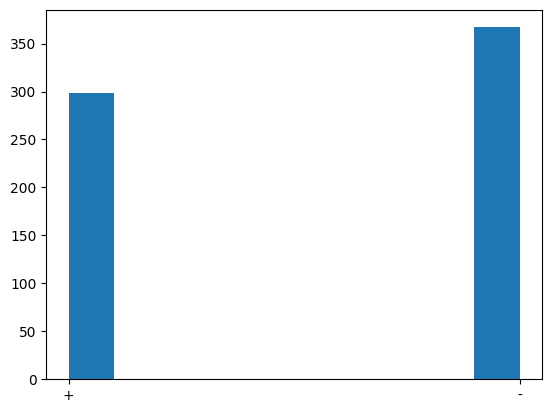

In [20]:
data = pd.read_csv('crx.data', sep=',')
d = data.values

# Variables caractéristiques
vc_cred = d[:,:-1]

# Variables à prédire
vp_cred = d[:,-1]

numeric_cols = [1, 2, 7, 10, 13, 14]

vc_num = vc_cred[:, numeric_cols]

vc_num = np.where(vc_num == "?", np.nan, vc_num)
vc_num = vc_num.astype(float)

mask = ~np.isnan(vc_num).any(axis=1)
vc_num_clean = vc_num[mask]
vp_clean = vp_cred[mask]

print("Taille :", vc_num_clean.shape)
print("Distribution de target :")
plt.hist(vp_clean)
plt.show()

vp_bin = np.where(vp_clean == "+", 1, 0)

In [21]:
results_raw = run_classifiers_cv(clfs, vc_num_clean, vp_bin)


=== CART ===
Accuracy :  0.716 +/- 0.058
AUC : 0.717 +/- 0.049
(Acc+Prec)/2 : 0.700 +/- 0.074
Temps : 0.54 sec

=== ID3 ===
Accuracy :  0.702 +/- 0.055
AUC : 0.704 +/- 0.049
(Acc+Prec)/2 : 0.686 +/- 0.069
Temps : 0.59 sec

=== DecisionStump ===
Accuracy :  0.744 +/- 0.054
AUC : 0.723 +/- 0.035
(Acc+Prec)/2 : 0.806 +/- 0.049
Temps : 0.21 sec

=== MLP ===
Accuracy :  0.661 +/- 0.080
AUC : 0.703 +/- 0.089
(Acc+Prec)/2 : 0.658 +/- 0.085
Temps : 4.17 sec

=== KNN ===
Accuracy :  0.689 +/- 0.041
AUC : 0.729 +/- 0.035
(Acc+Prec)/2 : 0.691 +/- 0.058
Temps : 0.29 sec

=== Bagging ===
Accuracy :  0.783 +/- 0.050
AUC : 0.836 +/- 0.046
(Acc+Prec)/2 : 0.789 +/- 0.056
Temps : 23.11 sec

=== AdaBoost ===
Accuracy :  0.795 +/- 0.047
AUC : 0.858 +/- 0.047
(Acc+Prec)/2 : 0.801 +/- 0.040
Temps : 14.93 sec

=== RandomForest ===
Accuracy :  0.767 +/- 0.063
AUC : 0.841 +/- 0.046
(Acc+Prec)/2 : 0.770 +/- 0.068
Temps : 14.34 sec

=== XGBoost ===
Accuracy :  0.756 +/- 0.055
AUC : 0.826 +/- 0.059
(Acc+Prec)/2 

**Observation :** On voit ici avec les données brutes, que le meilleur modèle est celui de *DecisionStump*, qui nous donne à la fois le meilleur score `((Acc+Prec)/2)` et est le plus court.

In [22]:
# Lecture du fichier
df = pd.read_csv('credit.data', header=None, sep=None, engine='python', na_values='?')

# Extraction des valeurs
vals = df.values

# Séparation des variables numériques et categorielles
col_num_idx = [1, 2, 7, 10, 13, 14]
col_cat_idx = [0, 3, 4, 5, 6, 8, 9, 11, 12]

X_num = vals[:, col_num_idx].astype(float)
X_cat = vals[:, col_cat_idx]


# Binarisation de la target
Y = vals[:, -1]
Y = np.where(Y == '+', 1, 0).astype(int)

# Transformation des données manquantes
imp_num = SimpleImputer(strategy='mean')
X_num_imputed = imp_num.fit_transform(X_num)

imp_cat = SimpleImputer(strategy='most_frequent')
X_cat_imputed = imp_cat.fit_transform(X_cat)


# Encodage des variables catégorielles
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_encoded = encoder.fit_transform(X_cat_imputed)


# Normalisation des variables numériques
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num_imputed)


# Construction du jeu final
X_final = np.concatenate([X_num_scaled, X_cat_encoded], axis=1)

print(X_final)

[[-0.05858175 -0.95795088 -0.29170752 ...  1.          0.
   0.        ]
 [ 2.30866796 -0.06198648  0.2429608  ...  1.          0.
   0.        ]
 [-0.59682495 -0.85750644 -0.21703318 ...  1.          0.
   0.        ]
 ...
 [-0.53305206  1.75404897 -0.06768448 ...  1.          0.
   0.        ]
 [-1.15632578 -0.91676866 -0.65313136 ...  1.          0.
   0.        ]
 [ 0.29599552 -0.27995091  1.8111221  ...  1.          0.
   0.        ]]


In [23]:
print(run_classifiers_cv(clfs, X_final, Y))


=== CART ===
Accuracy :  0.815 +/- 0.043
AUC : 0.814 +/- 0.046
(Acc+Prec)/2 : 0.804 +/- 0.051
Temps : 0.29 sec

=== ID3 ===
Accuracy :  0.820 +/- 0.044
AUC : 0.819 +/- 0.043
(Acc+Prec)/2 : 0.803 +/- 0.060
Temps : 0.34 sec

=== DecisionStump ===
Accuracy :  0.856 +/- 0.044
AUC : 0.866 +/- 0.040
(Acc+Prec)/2 : 0.823 +/- 0.057
Temps : 0.15 sec

=== MLP ===
Accuracy :  0.855 +/- 0.042
AUC : 0.920 +/- 0.038
(Acc+Prec)/2 : 0.843 +/- 0.046
Temps : 12.91 sec

=== KNN ===
Accuracy :  0.840 +/- 0.052
AUC : 0.900 +/- 0.037
(Acc+Prec)/2 : 0.841 +/- 0.044
Temps : 5.18 sec

=== Bagging ===
Accuracy :  0.875 +/- 0.037
AUC : 0.928 +/- 0.027
(Acc+Prec)/2 : 0.864 +/- 0.038
Temps : 28.79 sec

=== AdaBoost ===
Accuracy :  0.856 +/- 0.038
AUC : 0.928 +/- 0.024
(Acc+Prec)/2 : 0.843 +/- 0.050
Temps : 16.27 sec

=== RandomForest ===
Accuracy :  0.876 +/- 0.030
AUC : 0.931 +/- 0.030
(Acc+Prec)/2 : 0.865 +/- 0.033
Temps : 13.59 sec

=== XGBoost ===
Accuracy :  0.869 +/- 0.027
AUC : 0.924 +/- 0.023
(Acc+Prec)/2

**Observations :** Nous pouvons en conclure que RandomForest est le meilleur lorsque les valeurs sont complétées et nettoyées. Il possède le meilleur score, ainsi qu'un temps relativement faible.